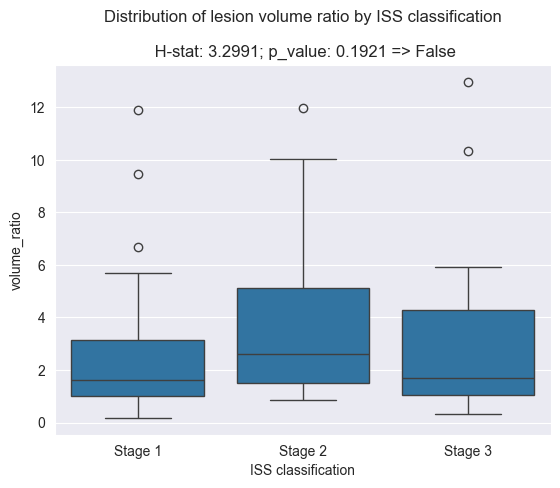

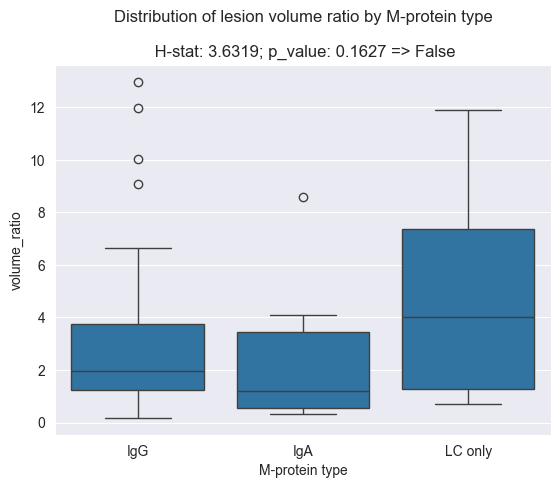

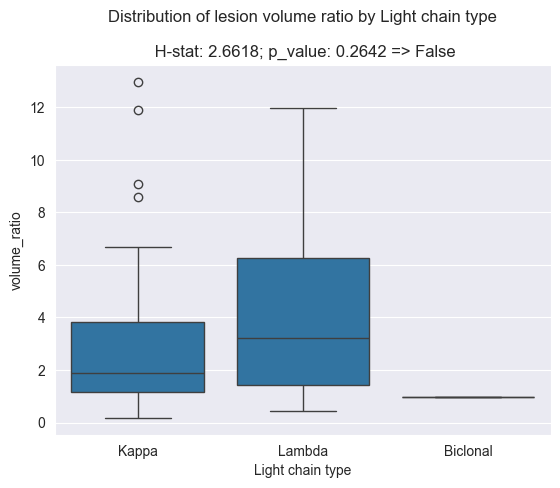

In [16]:
# RELATION BETWEEN LESIONS VOLUME RATIO AND CLINICAL VARIABLES -> KRUSKAL-WALLIS TEST
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, spearmanr
import matplotlib.pyplot as plt


df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df, left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100

for cat_col in categoric_features_clinical:
    groups = [group['volume_ratio'].dropna().values for name, group in df_final.groupby(cat_col)]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)


        sns.boxplot(data=df_final, x=cat_col, y="volume_ratio")
        plt.title(f'Distribution of lesion volume ratio by {cat_col}\n\n H-stat: {stat:.4f}; p_value: {p_value:.4f} => {p_value < 0.05}')
        plt.show()
        print()

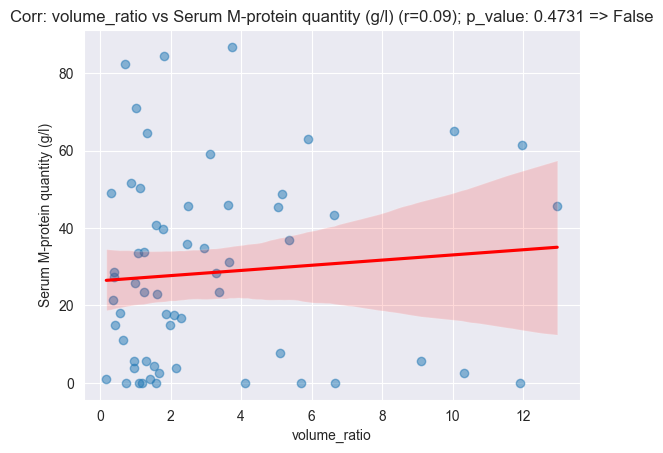

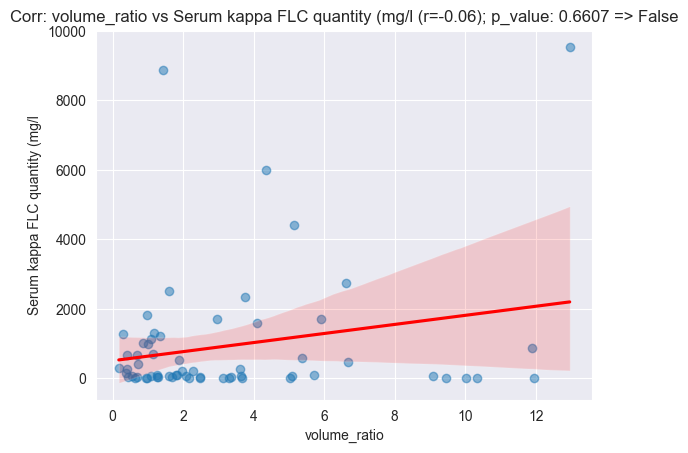

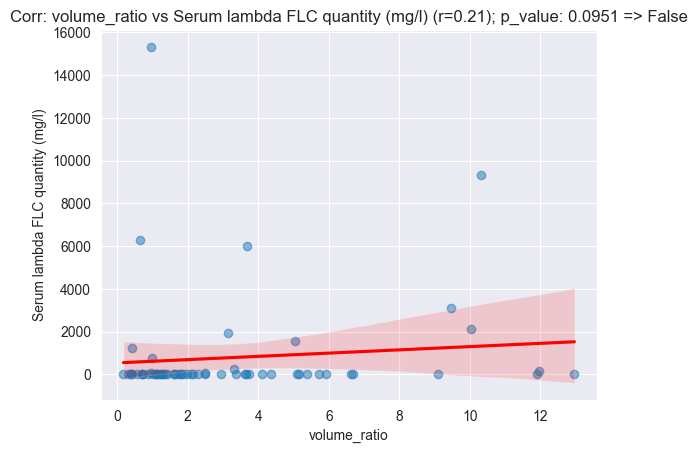

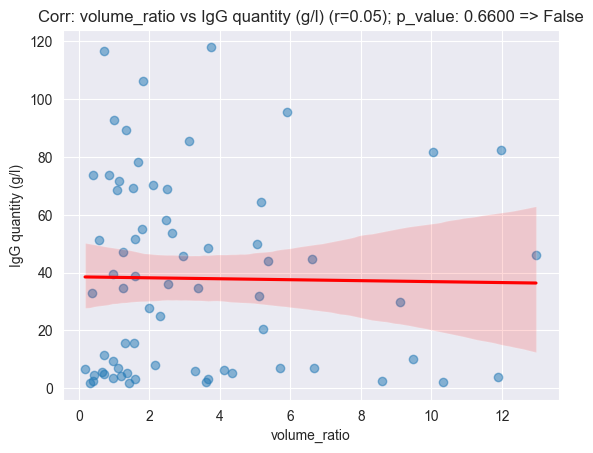

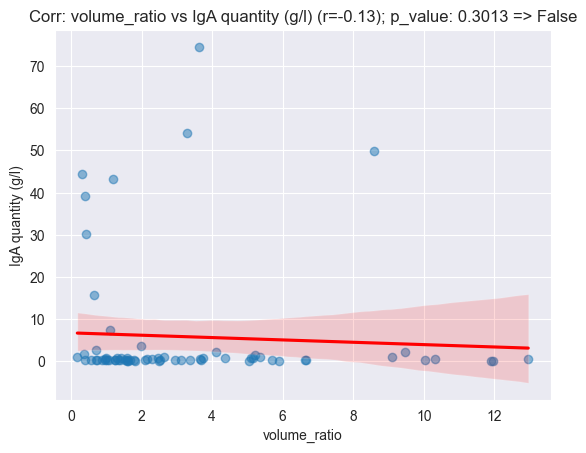

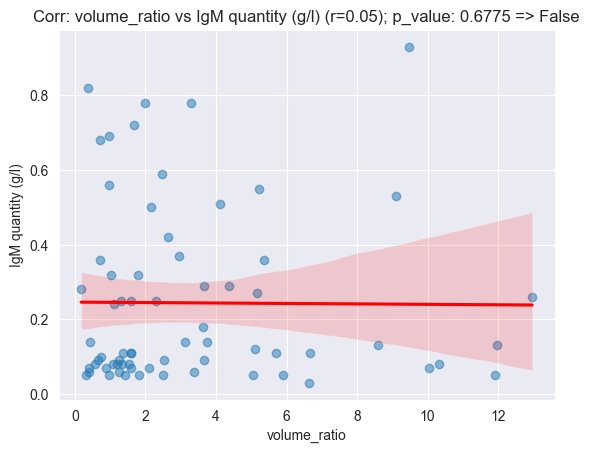

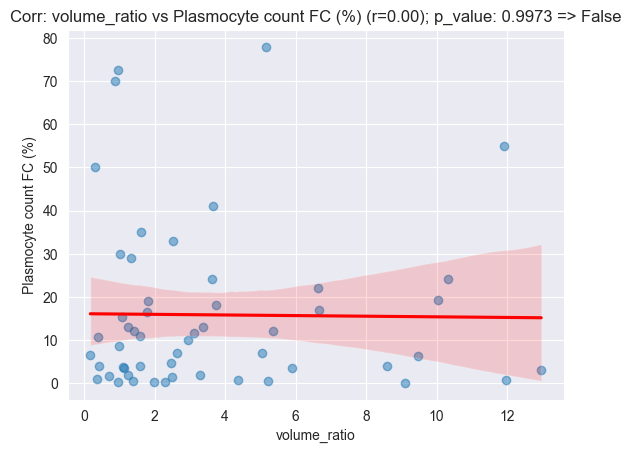

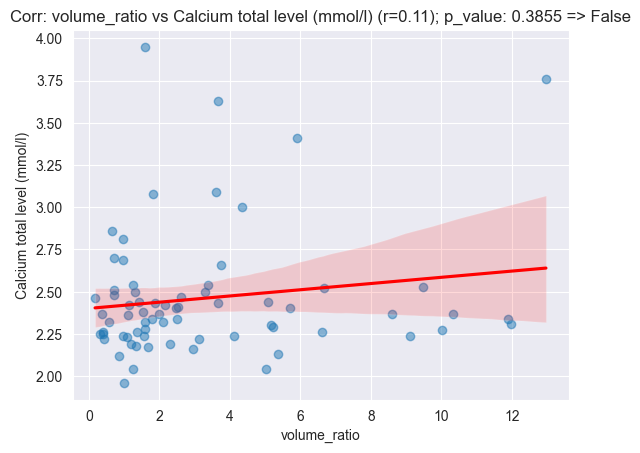

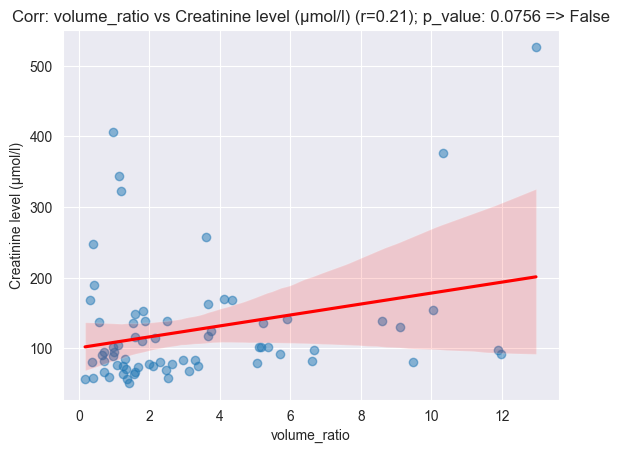

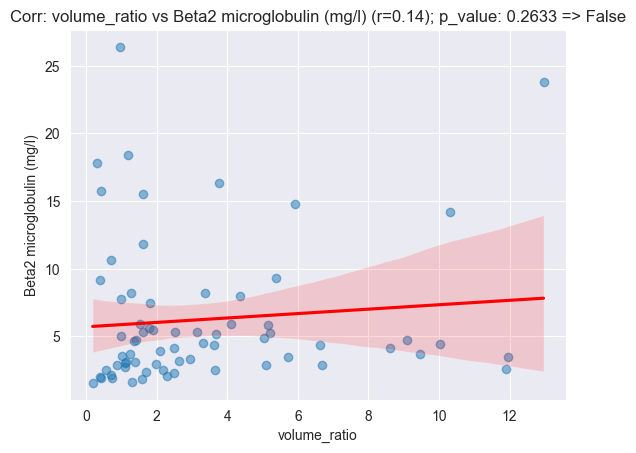

In [17]:
# RELATION BETWEEN LESIONS VOLUME RATIO AND CLINICAL VARIABLES -> SPEARMAN TEST
df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df, left_on='patient', right_on='Patient ID')

numeric_features_clinical = clinical_df.select_dtypes(include=['number']).columns

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100

for num_col in numeric_features_clinical:
    corr, p_value = spearmanr(df_final['volume_ratio'], df_final[num_col], nan_policy='omit')


    sns.regplot(data=df_final, x='volume_ratio', y=num_col,
                    scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

    plt.title(f"Corr: {'volume_ratio'} vs {num_col} (r={corr:.2f}); p_value: {p_value:.4f} => {p_value < 0.05}")
    plt.xlabel('volume_ratio')
    plt.ylabel(num_col)
    plt.show()
    print()

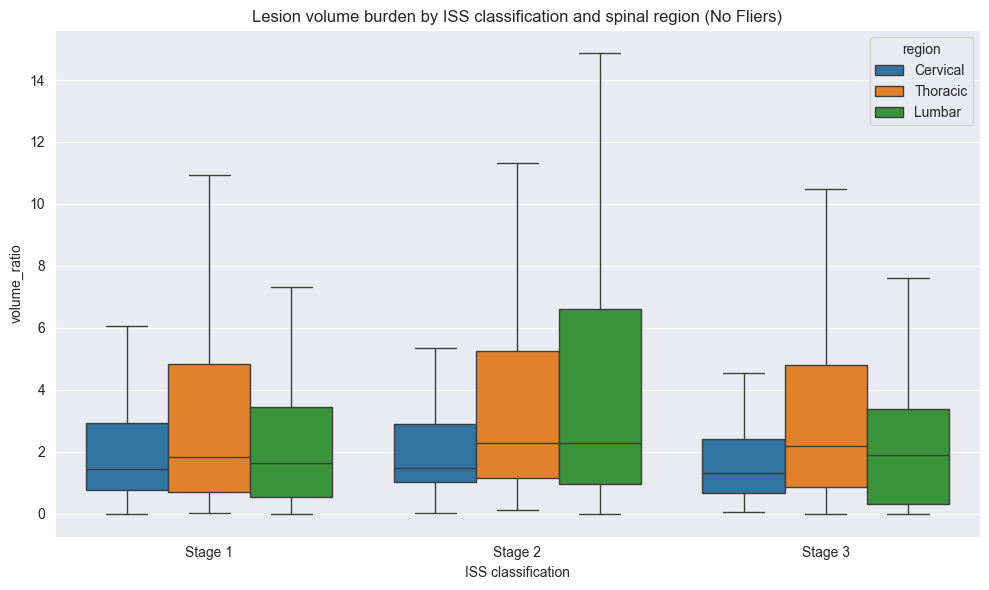


STATISTICAL ANALYSIS: Kruskal-Wallis Test

Region: Cervical
p-value: 0.4301
Significant (p < 0.05): NO

Region: Thoracic
p-value: 0.0807
Significant (p < 0.05): NO

Region: Lumbar
p-value: 0.0022
Significant (p < 0.05): YES


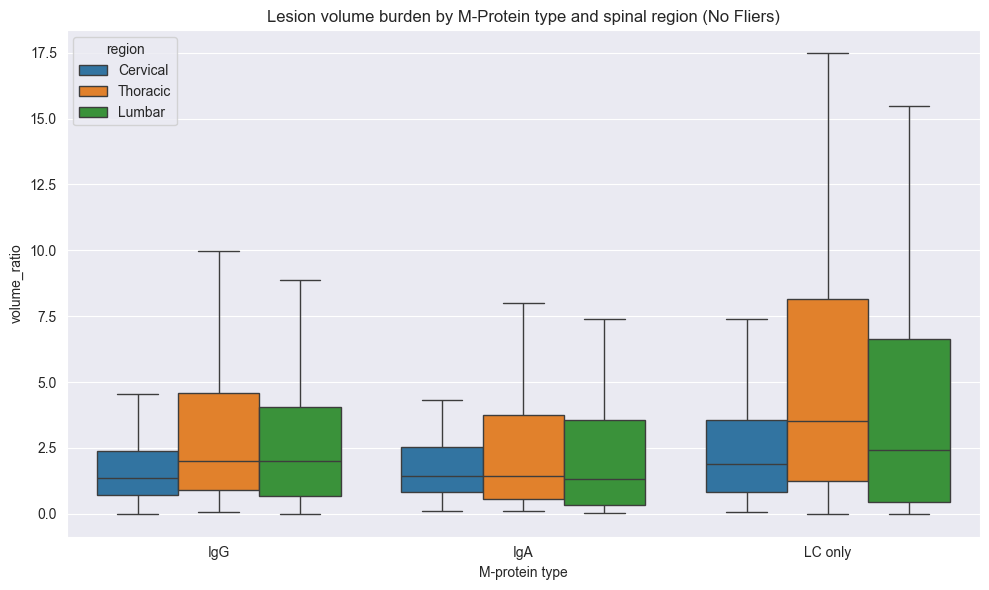


STATISTICAL ANALYSIS: Kruskal-Wallis Test

Region: Cervical
p-value: 0.0842
Significant (p < 0.05): NO

Region: Thoracic
p-value: 0.0000
Significant (p < 0.05): YES

Region: Lumbar
p-value: 0.2941
Significant (p < 0.05): NO


In [18]:
# RELATION BETWEEN CATEGORICAL VARIABLES SEPARATELY IN C/T/L VERTEBRAE -> KRUSKAL-WALLIS TEST
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# --- 1. Load and Clean Data ---
main_folder = r"E:\DATA_Myelomy"
lesion_data = []
vertebra_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    vertebra_csv = os.path.join(folder_path, "monoe_40kev_radiomics_vertebrae_features.csv")

    if os.path.isfile(lesion_csv):
        df_l = (pd.read_csv(lesion_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_l["patient"] = folder_name
        lesion_data.append(df_l)

    if os.path.isfile(vertebra_csv):
        df_v = (pd.read_csv(vertebra_csv).filter(items=["vertebra_name", "original_shape_VoxelVolume"]))
        df_v["patient"] = folder_name
        vertebra_data.append(df_v)

# Combine and merge
df_lesions = pd.concat(lesion_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "lesions_volume"})
df_vertebra = pd.concat(vertebra_data, ignore_index=True).rename(columns={"original_shape_VoxelVolume": "vertebra_volume"})
df = pd.merge(df_lesions, df_vertebra, on=["patient", "vertebra_name"])
df = df[df["vertebra_name"] != "S1"]

# Define regions
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical: return 'Cervical'
    elif vertebra in thoracic: return 'Thoracic'
    else: return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

# Merge clinical data
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')
df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100

# Plot 2: No Fliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.title("Lesion volume burden by ISS classification and spinal region (No Fliers)")
plt.tight_layout()
plt.show()

# --- 3. Statistical Analysis: Kruskal-Wallis ---
print("\n" + "="*50)
print("STATISTICAL ANALYSIS: Kruskal-Wallis Test")
print("="*50)

regions = ["Cervical", "Thoracic", "Lumbar"]

for region in regions:
    subset = df_final[df_final['region'] == region].dropna()
    groups = [group['volume_ratio'].values for name, group in subset.groupby('ISS classification')]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)
        print(f"\nRegion: {region}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
    else:
        print(f"\nRegion: {region}: Insufficient data to compare ISS groups.")





# M-PROTEIN TYPE
# Merge clinical data
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
df_final = pd.merge(df, clinical_df[['Patient ID', 'M-protein type']], left_on='patient', right_on='Patient ID')
df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebra_volume'] * 100

# Plot 2: No Fliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio", hue="region", hue_order=["Cervical", "Thoracic", "Lumbar"], showfliers=False)
plt.title("Lesion volume burden by M-Protein type and spinal region (No Fliers)")
plt.tight_layout()
plt.show()

# --- 3. Statistical Analysis: Kruskal-Wallis ---
print("\n" + "="*50)
print("STATISTICAL ANALYSIS: Kruskal-Wallis Test")
print("="*50)

regions = ["Cervical", "Thoracic", "Lumbar"]

for region in regions:
    subset = df_final[df_final['region'] == region].dropna()
    groups = [group['volume_ratio'].values for name, group in subset.groupby('M-protein type')]

    if len(groups) > 1:
        stat, p_value = kruskal(*groups)
        print(f"\nRegion: {region}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
    else:
        print(f"\nRegion: {region}: Insufficient data to compare M-Protein type.")